# Adjust Formation Expansion Data

2026/01/16

During the first hour of formation charge, we see a ''kink'' in the data. We're not sure exactly what it is, but we've decided to get rid of it because we don't believe it is electrochemical in nature and it is interfering with the process of identifying VC parameters during the VC-dominant region.

In [1]:
import os, sys

# Move the path up a level to be able to index into source files
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('../')
    sys.path.insert(0, 'src/')

from src import cellsim as cellsim

from scipy.interpolate import interp1d

import pickle
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from src import plotter as plotter
from src import ioutils as ioutils 
from src import simutils as simutils

%load_ext autoreload
%matplotlib widget

plotter.initialize(plt)

# What is the kink?

In [2]:
expt1, _ = ioutils.fetch_experimental_data(152064, 400)
expt2, _ = ioutils.fetch_experimental_data(152074, 400)
expt3, _ = ioutils.fetch_experimental_data(152071, 400)
expt4, _ = ioutils.fetch_experimental_data(152098, 400)

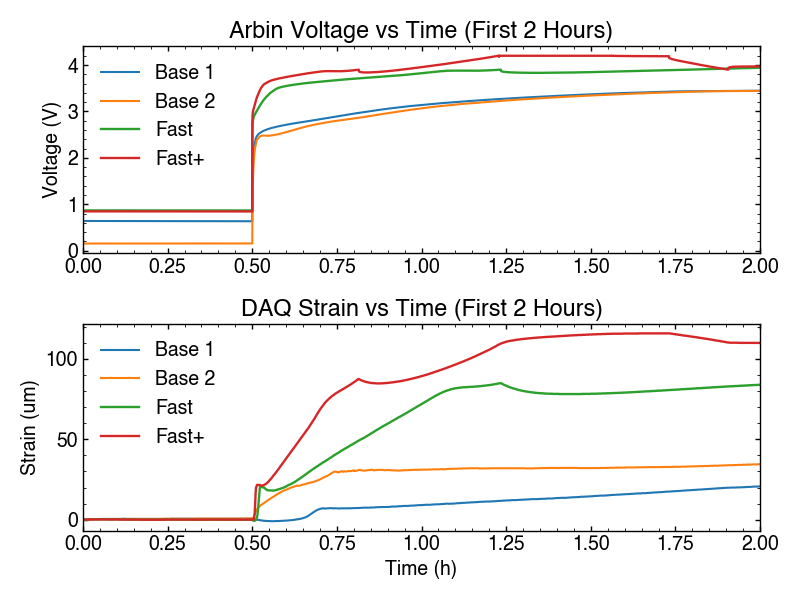

In [5]:
expt1.keys()

import matplotlib.dates as mdates

# Plot Arbin voltage and DAQ strain for the first two hours across all experiments

# Collect experiment data and plot styles
expts = [expt1, expt2, expt3, expt4]
labels = ['Base 1', 'Base 2', 'Fast', 'Fast+']
color_map = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red']
linewidths = [1.5, 1.5, 1.7, 1.7]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8,6), sharex=False)

# We'll align both Arbin and DAQ time axes to start at zero.
for idx, (expt, label, color) in enumerate(zip(expts, labels, color_map)):
    # Convert Arbin & DAQ time to hours from zero
    arbin_time = np.array(expt['arbin_time'])
    daq_time = np.array(expt['daq_time'])

    # Reference start time for zeroing axis
    arbin_time_zero = (arbin_time - arbin_time[0]) / 3600.0  # hours
    daq_time_zero = (daq_time - daq_time[0]) / 3600.0  # hours

    # Get data for axes
    arbin_voltage = np.array(expt['arbin_voltage'])
    daq_strain = np.array(expt['daq_strain'])

    # Mask for first 2 hours
    arbin_mask = arbin_time_zero <= 2.0
    daq_mask = daq_time_zero <= 2.0

    # Plot Arbin Voltage vs Time
    ax1.plot(arbin_time_zero[arbin_mask], arbin_voltage[arbin_mask], 
            label=label, color=color, linewidth=linewidths[idx])

    # Plot DAQ Strain vs Time
    ax2.plot(daq_time_zero[daq_mask], daq_strain[daq_mask], label=label, 
            color=color, linewidth=linewidths[idx])

ax1.set_title('Arbin Voltage vs Time (First 2 Hours)')
ax1.set_ylabel('Voltage (V)')
ax1.set_xlim([0, 2])
ax1.legend()
ax1.grid(False)

ax2.set_title('DAQ Strain vs Time (First 2 Hours)')
ax2.set_xlabel('Time (h)')
ax2.set_ylabel('Strain (um)')
ax2.set_xlim([0, 2])
ax2.legend()
ax2.grid(False)

plt.tight_layout()
plt.show()

# Smoothing the kinks

For each strain dataset, we clean up the data by smoothing out the "kink" that occurs within the first section of each charge. Within the affected regions, we replace the data with a smooth curve that connects the two endpoints. We use cubic Hermite interpolation to ensure derivative continuity at the right endpoint.

In [6]:
def smooth_kink_region(time_hours, strain, t_start, t_end, deriv_window=0.05):
    """
    Replace data in [t_start, t_end] with a smooth cubic Hermite curve.
    
    The curve matches:
    - Value at t_start (left endpoint)
    - Value at t_end (right endpoint)  
    - Derivative at t_end (for continuity)
    
    Parameters:
    -----------
    time_hours : array-like
        Time in hours
    strain : array-like
        Strain data
    t_start : float
        Start of affected region (hours)
    t_end : float
        End of affected region (hours)
    deriv_window : float
        Time window after t_end to estimate derivative (hours)
    
    Returns:
    --------
    strain_smoothed : array
        Strain with smoothed region
    """
    time_hours = np.array(time_hours)
    strain = np.array(strain)
    strain_smoothed = strain.copy()
    
    # Find indices for the affected region
    mask_region = (time_hours >= t_start) & (time_hours <= t_end)
    idx_region = np.where(mask_region)[0]
    
    if len(idx_region) == 0:
        return strain_smoothed
    
    # Get endpoint values
    # Left endpoint: closest point at or just before t_start
    idx_left = np.searchsorted(time_hours, t_start)
    if idx_left > 0:
        idx_left -= 1
    t_left = time_hours[idx_left]
    y_left = strain[idx_left]
    
    # Right endpoint: closest point at or just after t_end
    idx_right = np.searchsorted(time_hours, t_end)
    if idx_right >= len(time_hours):
        idx_right = len(time_hours) - 1
    t_right = time_hours[idx_right]
    y_right = strain[idx_right]
    
    # Estimate derivative at right endpoint using data just after t_end
    mask_deriv = (time_hours > t_end) & (time_hours <= t_end + deriv_window)
    if np.sum(mask_deriv) >= 2:
        t_deriv = time_hours[mask_deriv]
        y_deriv = strain[mask_deriv]
        # Linear fit to estimate slope
        dy_right = np.polyfit(t_deriv, y_deriv, 1)[0]
    else:
        # Fallback: use simple difference
        dy_right = (strain[idx_right + 1] - strain[idx_right]) / (time_hours[idx_right + 1] - time_hours[idx_right])
    
    # For left endpoint, we can allow a discontinuity, so set derivative to match the general trend
    # Use a simple linear slope from left to right as a starting guide
    dy_left = (y_right - y_left) / (t_right - t_left)
    
    # Cubic Hermite interpolation
    # h(t) = a*t^3 + b*t^2 + c*t + d
    # where t is normalized to [0, 1]
    # h(0) = y_left, h(1) = y_right
    # h'(0) = dy_left * dt, h'(1) = dy_right * dt
    
    dt = t_right - t_left
    
    # Hermite basis functions for normalized t in [0,1]:
    # h(s) = (2s^3 - 3s^2 + 1)*y0 + (s^3 - 2s^2 + s)*m0 + (-2s^3 + 3s^2)*y1 + (s^3 - s^2)*m1
    # where m0 = dy0 * dt, m1 = dy1 * dt
    
    m0 = dy_left * dt
    m1 = dy_right * dt
    
    # Apply smoothing to points in the region
    t_region = time_hours[mask_region]
    s = (t_region - t_left) / dt  # Normalize to [0, 1]
    
    # Hermite interpolation
    h00 = 2*s**3 - 3*s**2 + 1
    h10 = s**3 - 2*s**2 + s
    h01 = -2*s**3 + 3*s**2
    h11 = s**3 - s**2
    
    strain_smoothed[mask_region] = h00*y_left + h10*m0 + h01*y_right + h11*m1
    
    return strain_smoothed

In [7]:
# Define affected regions for each dataset
# Format: (expt, label, t_start, t_end)
kink_regions = [
    (expt1, 'Base 1', 0.5, 0.75),
    (expt2, 'Base 2', 0.5, 0.85),
    (expt3, 'Fast', 0.5, 0.6),
    (expt4, 'Fast+', 0.5, 0.55),
]

# Apply smoothing to each dataset
smoothed_strains = {}
for expt, label, t_start, t_end in kink_regions:
    daq_time = np.array(expt['daq_time'])
    daq_strain = np.array(expt['daq_strain'])
    
    # Convert to hours from zero
    daq_time_hours = (daq_time - daq_time[0]) / 3600.0
    
    # Apply smoothing
    strain_smoothed = smooth_kink_region(daq_time_hours, daq_strain, t_start, t_end)
    smoothed_strains[label] = {
        'time_hours': daq_time_hours,
        'original': daq_strain,
        'smoothed': strain_smoothed,
        't_start': t_start,
        't_end': t_end
    }
    
print("Smoothing complete for all datasets")

Smoothing complete for all datasets


In [8]:
# Update the original experiment dictionaries with the smoothed strain data
# Ensure dimensions are compatible with daq_time and daq_strain

expt_label_mapping = [
    (expt1, 'Base 1'),
    (expt2, 'Base 2'),
    (expt3, 'Fast'),
    (expt4, 'Fast+'),
]

for expt, label in expt_label_mapping:
    smoothed_data = smoothed_strains[label]['smoothed']
    
    # Verify dimensions match original data
    assert len(smoothed_data) == len(expt['daq_time']), \
        f"{label}: smoothed data length ({len(smoothed_data)}) != daq_time length ({len(expt['daq_time'])})"
    assert len(smoothed_data) == len(expt['daq_strain']), \
        f"{label}: smoothed data length ({len(smoothed_data)}) != daq_strain length ({len(expt['daq_strain'])})"
    
    # Add smoothed strain to the experiment dictionary
    expt['daq_strain_smoothed'] = smoothed_data
    
    print(f"{label}: daq_strain_smoothed added with shape {smoothed_data.shape}, "
          f"matching daq_time ({len(expt['daq_time'])}) and daq_strain ({len(expt['daq_strain'])})")

Base 1: daq_strain_smoothed added with shape (287985,), matching daq_time (287985) and daq_strain (287985)
Base 2: daq_strain_smoothed added with shape (287985,), matching daq_time (287985) and daq_strain (287985)
Fast: daq_strain_smoothed added with shape (287985,), matching daq_time (287985) and daq_strain (287985)
Fast+: daq_strain_smoothed added with shape (287985,), matching daq_time (287985) and daq_strain (287985)


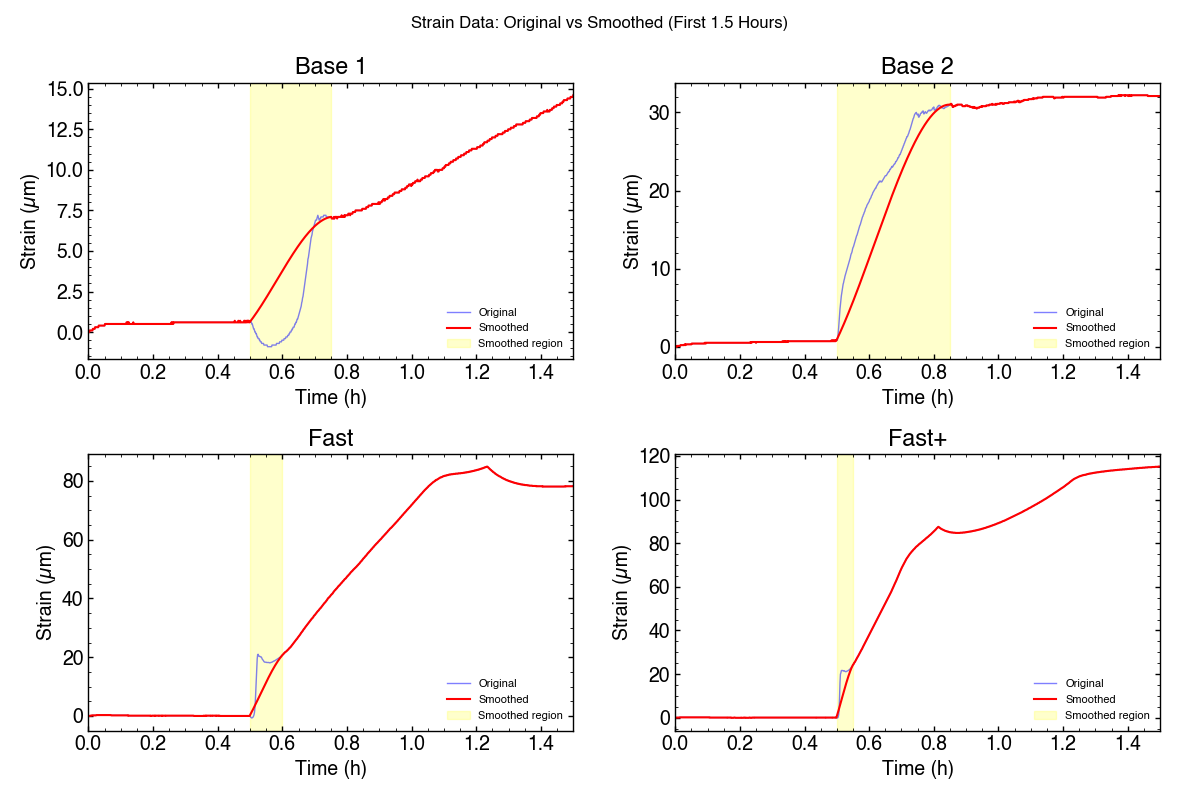

In [9]:

# Visualize before/after comparison for each dataset
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for idx, (label, data) in enumerate(smoothed_strains.items()):
    ax = axes[idx]
    t = data['time_hours']
    t_start = data['t_start']
    t_end = data['t_end']
    
    # Focus on the region around the kink (0 to 1.5 hours)
    mask_plot = t <= 1.5
    
    ax.plot(t[mask_plot], data['original'][mask_plot], 'b-', alpha=0.5, linewidth=1, label='Original')
    ax.plot(t[mask_plot], data['smoothed'][mask_plot], 'r-', linewidth=1.5, label='Smoothed')
    
    # Highlight the affected region
    ax.axvspan(t_start, t_end, alpha=0.2, color='yellow', label=f'Smoothed region')
    
    ax.set_title(f'{label}')
    ax.grid(False)
    ax.set_xlabel('Time (h)')
    ax.set_ylabel('Strain (µm)')
    ax.legend(loc='lower right', fontsize=8)
    ax.set_xlim([0, 1.5])

plt.suptitle('Strain Data: Original vs Smoothed (First 1.5 Hours)', fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
# Overlay plot: original (solid), smoothed (dashed), no gridlines

plt.figure(figsize=(10, 6))

labels_list = ['Base 1', 'Base 2', 'Fast', 'Fast+']
color_map = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red']
linewidths = [1.5, 1.5, 1.7, 1.7]

for idx, label in enumerate(labels_list):
    data = smoothed_strains[label]
    t = data['time_hours']
    mask = t <= 2.0

    # Original data (solid line)
    plt.plot(t[mask], data['original'][mask], 
             color=color_map[idx], 
             linewidth=linewidths[idx], 
             linestyle='-', 
             label=f'{label} Original')

    # Smoothed data (dashed line)
    plt.plot(t[mask], data['smoothed'][mask], 
             color=color_map[idx], 
             linewidth=linewidths[idx] + 0.5, 
             linestyle='--', 
             label=f'{label} Smoothed')

plt.title('Strain Data: Original (Solid) vs Smoothed (Dashed)')
plt.xlabel('Time (h)')
plt.ylabel('Strain (µm)')
plt.xlim([0.25, 1.00])
plt.grid(False)
plt.legend(fontsize=9, ncol=2)
plt.tight_layout()
plt.show()


# Use the smoothed dataset to repeat the $\rho_{VC}$ optimization

In [ ]:
%matplotlib widget 

# Optimized densities from baseline formation, expansion RMSE
rho_vc_opt = 1.3
rho_ec_opt = 0.8

d_ec = 3.86e-20
d_vc = 1.585e-17

df_fast = simutils.run_sim('fast', d_ec, d_vc, rho_ec=rho_ec_opt, rho_vc=rho_vc_opt, dt=1, include_flag=1)


fig, axes = plt.subplots(2, 1, figsize=(7, 7), sharex=True)

# Experimental data (fast protocol)
exp_time = expt3['daq_time'] / 3600  # convert seconds to hours
exp_strain = expt3['daq_strain']
exp_strain_smoothed = expt3['daq_strain_smoothed']

# Model data
model_time = df_fast['t'] / 3600  # convert seconds to hours
model_expansion = df_fast['expansion'] * 1e6  # convert m to um

# Top plot: Expansion
axes[0].plot(exp_time, exp_strain, label='Experimental', color='k', lw=2)
axes[0].plot(exp_time, exp_strain_smoothed, label='Smoothed', color='k', lw=2, linestyle='--')
axes[0].plot(model_time, model_expansion, label='Model', color='tab:blue', lw=2)
axes[0].set_ylabel('Expansion (µm)')
axes[0].set_title('Model vs Experimental Expansion (Fast Protocol)')
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.5)

# Bottom plot: SEI current densities
axes[1].plot(model_time, df_fast['j_sei1'], label='j_sei1 (EC)', color='tab:orange', lw=2)
axes[1].plot(model_time, df_fast['j_sei2'], label='j_sei2 (VC)', color='tab:green', lw=2)
axes[1].set_xlabel('Time (hours)')
axes[1].set_ylabel('Current density (A/m²)')
axes[1].set_title('SEI Current Densities (Fast Protocol)')
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.5)

# Set shared x-axis limits
axes[1].set_xlim(0.4, 1)

plt.tight_layout()
plt.show()

In [11]:
nn = 30

rho_ec_vec = np.linspace(0.1, 4, nn)
rho_vc_vec = np.linspace(0.1, 4, nn+1)

rmse1_e_mat = np.zeros((len(rho_ec_vec), len(rho_vc_vec)))
rmse1_v_mat = np.zeros((len(rho_ec_vec), len(rho_vc_vec)))
rmse2_e_mat = np.zeros((len(rho_ec_vec), len(rho_vc_vec)))
rmse2_v_mat = np.zeros((len(rho_ec_vec), len(rho_vc_vec)))
rmse3_e_mat = np.zeros((len(rho_ec_vec), len(rho_vc_vec)))
rmse3_v_mat = np.zeros((len(rho_ec_vec), len(rho_vc_vec)))
qsei1_mat = np.zeros((len(rho_ec_vec), len(rho_vc_vec)))
qsei2_mat = np.zeros((len(rho_ec_vec), len(rho_vc_vec)))
qsei3_mat = np.zeros((len(rho_ec_vec), len(rho_vc_vec)))
qsei1_vc_mat = np.zeros((len(rho_ec_vec), len(rho_vc_vec)))
qsei2_vc_mat = np.zeros((len(rho_ec_vec), len(rho_vc_vec)))
qsei3_vc_mat = np.zeros((len(rho_ec_vec), len(rho_vc_vec)))

expan1_mat = np.zeros((len(rho_ec_vec), len(rho_vc_vec)))
expan2_mat = np.zeros((len(rho_ec_vec), len(rho_vc_vec)))
expan3_mat = np.zeros((len(rho_ec_vec), len(rho_vc_vec)))

resistance1_mat = np.zeros((len(rho_ec_vec), len(rho_vc_vec)))
resistance2_mat = np.zeros((len(rho_ec_vec), len(rho_vc_vec)))   
resistance3_mat = np.zeros((len(rho_ec_vec), len(rho_vc_vec)))

crossover1_mat = np.zeros((len(rho_ec_vec), len(rho_vc_vec)))
crossover2_mat = np.zeros((len(rho_ec_vec), len(rho_vc_vec)))
crossover3_mat = np.zeros((len(rho_ec_vec), len(rho_vc_vec)))

count = 1

for i, rho_ec in enumerate(rho_ec_vec):
    for j, rho_vc in enumerate(rho_vc_vec):

        print(f'Running rho_EC = {rho_ec:.2e} | rho_VC = {rho_vc:.2e} ({count} of {nn*(nn+1)})')
        count += 1

        try:
            df_sim1 = simutils.run_sim('base', diff_vc=6.31e-17, rho_ec=rho_ec, rho_vc=rho_vc, dt=1, include_flag=1)
            df_sim2 = simutils.run_sim('fast', diff_vc=6.31e-17, rho_ec=rho_ec, rho_vc=rho_vc, dt=1, include_flag=1)
            df_sim3 = simutils.run_sim('fast+', diff_vc=6.31e-17, rho_ec=rho_ec, rho_vc=rho_vc, dt=1, include_flag=1)

            # Restrict simulated dataset to just before the point at which EC reaction overtakes EC reaction
            # I.e., focus on VC reaction region
            crossover1_idx = df_sim1[df_sim1['j_sei1'] > df_sim1['j_sei2']].index
            if len(crossover1_idx) > 0:
                df_sim1 = df_sim1.loc[:crossover1_idx[0]-1]

            crossover2_idx = df_sim2[df_sim2['j_sei1'] > df_sim2['j_sei2']].index
            if len(crossover2_idx) > 0:
                df_sim2 = df_sim2.loc[:crossover2_idx[0]-1]

            crossover3_idx = df_sim3[df_sim3['j_sei1'] > df_sim3['j_sei2']].index
            if len(crossover3_idx) > 0:
                df_sim3 = df_sim3.loc[:crossover3_idx[0]-1]

        except:
            print('ERROR')
            continue

        crossover1_mat[i,j] = crossover1_idx[0] if len(crossover1_idx) > 0 else np.nan
        crossover2_mat[i,j] = crossover2_idx[0] if len(crossover2_idx) > 0 else np.nan
        crossover3_mat[i,j] = crossover3_idx[0] if len(crossover3_idx) > 0 else np.nan
        
        # Extract the qsei values:
        qsei1_mat[i, j] = df_sim1['q_sei'].iloc[-1]
        qsei2_mat[i, j] = df_sim2['q_sei'].iloc[-1]
        qsei3_mat[i, j] = df_sim3['q_sei'].iloc[-1]

        qsei1_vc_mat[i, j] = df_sim1['q_sei2'].iloc[-1]
        qsei2_vc_mat[i, j] = df_sim2['q_sei2'].iloc[-1]
        qsei3_vc_mat[i, j] = df_sim3['q_sei2'].iloc[-1]

        # Extract the expansion values:
        expan1_mat[i, j] = df_sim1['expansion'].iloc[-1]
        expan2_mat[i, j] = df_sim2['expansion'].iloc[-1]
        expan3_mat[i, j] = df_sim3['expansion'].iloc[-1]

        # Extract the resistance values:
        resistance1_mat[i, j] = df_sim1['R_sei'].iloc[-1]
        resistance2_mat[i, j] = df_sim2['R_sei'].iloc[-1]
        resistance3_mat[i, j] = df_sim3['R_sei'].iloc[-1]

        # Beware of experimental vs model data indexing!!
        rmse1_v, _, _ = simutils.calculate_rmse(expt2['arbin_time'], expt2['arbin_voltage'], df_sim1['t'], df_sim1['vt'])
        rmse1_e, _, _ = simutils.calculate_rmse(expt2['daq_time'],   expt2['daq_strain_smoothed'], df_sim1['t'], df_sim1['expansion']*1e6)
        rmse2_v, _, _ = simutils.calculate_rmse(expt3['arbin_time'], expt3['arbin_voltage'], df_sim2['t'], df_sim2['vt'])
        rmse2_e, _, _ = simutils.calculate_rmse(expt3['daq_time'],   expt3['daq_strain_smoothed'], df_sim2['t'], df_sim2['expansion']*1e6)
        rmse3_v, _, _ = simutils.calculate_rmse(expt4['arbin_time'], expt4['arbin_voltage'], df_sim3['t'], df_sim3['vt'])
        rmse3_e, _, _ = simutils.calculate_rmse(expt4['daq_time'],   expt4['daq_strain_smoothed'], df_sim3['t'], df_sim3['expansion']*1e6)

        rmse1_e, _, _ = simutils.calculate_rmse(smoothed_strains['Base 1']['time_hours']*3600, smoothed_strains['Base 1']['smoothed'], df_sim1['t'], df_sim1['expansion']*1e6)

        rmse1_e_mat[i, j] = rmse1_e
        rmse1_v_mat[i, j] = rmse1_v
        rmse2_e_mat[i, j] = rmse2_e
        rmse2_v_mat[i, j] = rmse2_v
        rmse3_e_mat[i, j] = rmse3_e
        rmse3_v_mat[i, j] = rmse3_v

# Replace zeros with np.nan in rmse1_e_mat
rmse1_e_mat = np.where(rmse1_e_mat == 0, np.nan, rmse1_e_mat)
rmse1_v_mat = np.where(rmse1_v_mat == 0, np.nan, rmse1_v_mat)
rmse2_e_mat = np.where(rmse2_e_mat == 0, np.nan, rmse2_e_mat)
rmse2_v_mat = np.where(rmse2_v_mat == 0, np.nan, rmse2_v_mat)
rmse3_e_mat = np.where(rmse3_e_mat == 0, np.nan, rmse3_e_mat)
rmse3_v_mat = np.where(rmse3_v_mat == 0, np.nan, rmse3_v_mat)
qsei1_mat = np.where(qsei1_mat == 0, np.nan, qsei1_mat)
qsei2_mat = np.where(qsei2_mat == 0, np.nan, qsei2_mat)
qsei3_mat = np.where(qsei3_mat == 0, np.nan, qsei3_mat)
qsei1_vc_mat = np.where(qsei1_vc_mat == 0, np.nan, qsei1_vc_mat)
qsei2_vc_mat = np.where(qsei2_vc_mat == 0, np.nan, qsei2_vc_mat)
qsei3_vc_mat = np.where(qsei3_vc_mat == 0, np.nan, qsei3_vc_mat)

expan1_mat = np.where(expan1_mat == 0, np.nan, expan1_mat)
expan2_mat = np.where(expan2_mat == 0, np.nan, expan2_mat)
expan3_mat = np.where(expan3_mat == 0, np.nan, expan3_mat)

resistance1_mat = np.where(resistance1_mat == 0, np.nan, resistance1_mat)
resistance2_mat = np.where(resistance2_mat == 0, np.nan, resistance2_mat)
resistance3_mat = np.where(resistance3_mat == 0, np.nan, resistance3_mat)

combined_rmse1 = rmse1_e_mat/np.nanmax(rmse1_e_mat) + rmse1_v_mat/np.nanmax(rmse1_v_mat)
combined_rmse2 = rmse2_e_mat/np.nanmax(rmse2_e_mat) + rmse2_v_mat/np.nanmax(rmse2_v_mat)
combined_rmse3 = rmse3_e_mat/np.nanmax(rmse3_e_mat) + rmse3_v_mat/np.nanmax(rmse3_v_mat)

# Compute error metrics based on cell capacity and resistance
# Rother = 0.01 + 0.001 + 0.001 # R0p + Rdiffp + Rdiffn
Rother = 0.0215 - 0.09197987391102377 # This value gets the R error to 0 for the base case
Rmeas1 = 0.0215 
Rmeas2 = 0.0178 
Rmeas3 = 0.0166 
Q_max  = 2.87
Q_meas = 2.54

# Capacity error
eq1_mat = (qsei1_mat - (Q_max - Q_meas))**2
eq2_mat = (qsei2_mat - (Q_max - Q_meas))**2
eq3_mat = (qsei3_mat - (Q_max - Q_meas))**2

# Resistance error
er1_mat = ((resistance1_mat + Rother) - Rmeas1)**2
er2_mat = ((resistance2_mat + Rother) - Rmeas2)**2
er3_mat = ((resistance3_mat + Rother) - Rmeas3)**2

# Combined capacity and resistance error
ec1_mat = (eq1_mat / np.nanmax(eq1_mat)) + (er1_mat / np.nanmax(er1_mat))
ec2_mat = (eq2_mat / np.nanmax(eq2_mat)) + (er2_mat / np.nanmax(er2_mat))
ec3_mat = (eq3_mat / np.nanmax(eq3_mat)) + (er3_mat / np.nanmax(er3_mat))

Running rho_EC = 1.00e-01 | rho_VC = 1.00e-01 (1 of 930)
Running rho_EC = 1.00e-01 | rho_VC = 2.30e-01 (2 of 930)
Running rho_EC = 1.00e-01 | rho_VC = 3.60e-01 (3 of 930)
Running rho_EC = 1.00e-01 | rho_VC = 4.90e-01 (4 of 930)
Running rho_EC = 1.00e-01 | rho_VC = 6.20e-01 (5 of 930)
Running rho_EC = 1.00e-01 | rho_VC = 7.50e-01 (6 of 930)
Running rho_EC = 1.00e-01 | rho_VC = 8.80e-01 (7 of 930)
Running rho_EC = 1.00e-01 | rho_VC = 1.01e+00 (8 of 930)
Running rho_EC = 1.00e-01 | rho_VC = 1.14e+00 (9 of 930)
Running rho_EC = 1.00e-01 | rho_VC = 1.27e+00 (10 of 930)
Running rho_EC = 1.00e-01 | rho_VC = 1.40e+00 (11 of 930)
Running rho_EC = 1.00e-01 | rho_VC = 1.53e+00 (12 of 930)
Running rho_EC = 1.00e-01 | rho_VC = 1.66e+00 (13 of 930)
Running rho_EC = 1.00e-01 | rho_VC = 1.79e+00 (14 of 930)
Running rho_EC = 1.00e-01 | rho_VC = 1.92e+00 (15 of 930)
Running rho_EC = 1.00e-01 | rho_VC = 2.05e+00 (16 of 930)
Running rho_EC = 1.00e-01 | rho_VC = 2.18e+00 (17 of 930)
Running rho_EC = 1.00e-

In [12]:
variables_to_pickle = {
    'rmse1_e_mat': rmse1_e_mat,
    'rmse1_v_mat': rmse1_v_mat,
    'rmse2_e_mat': rmse2_e_mat,
    'rmse2_v_mat': rmse2_v_mat,
    'rmse3_e_mat': rmse3_e_mat,
    'rmse3_v_mat': rmse3_v_mat,
    'qsei1_mat': qsei1_mat,
    'qsei2_mat': qsei2_mat,
    'qsei3_mat': qsei3_mat,
    'qsei1_vc_mat': qsei1_vc_mat,
    'qsei2_vc_mat': qsei2_vc_mat,
    'qsei3_vc_mat': qsei3_vc_mat,
    'expan1_mat': expan1_mat,
    'expan2_mat': expan2_mat,
    'expan3_mat': expan3_mat,
    'resistance1_mat': resistance1_mat,
    'resistance2_mat': resistance2_mat,
    'resistance3_mat': resistance3_mat,
    'combined_rmse1': combined_rmse1,
    'combined_rmse2': combined_rmse2,
    'combined_rmse3': combined_rmse3,
    'eq1_mat': eq1_mat,
    'eq2_mat': eq2_mat,
    'eq3_mat': eq3_mat,
    'er1_mat': er1_mat,
    'er2_mat': er2_mat,
    'er3_mat': er3_mat,
    'ec1_mat': ec1_mat,
    'ec2_mat': ec2_mat,
    'ec3_mat': ec3_mat,
    'crossover1_mat': crossover1_mat,
    'crossover2_mat': crossover2_mat,
    'crossover3_mat': crossover3_mat
}

with open('outputs/simulation_results_density_vc_20260120.pkl', 'wb') as f:
    pickle.dump(variables_to_pickle, f)

In [ ]:
import pickle
import numpy as np

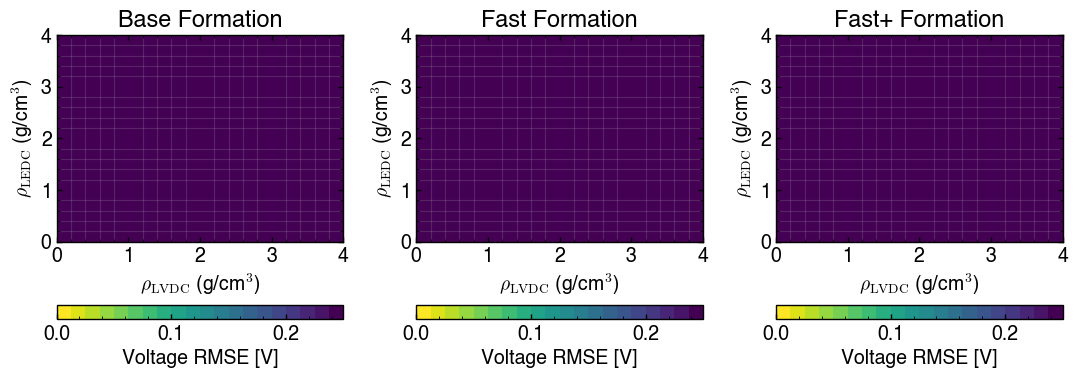

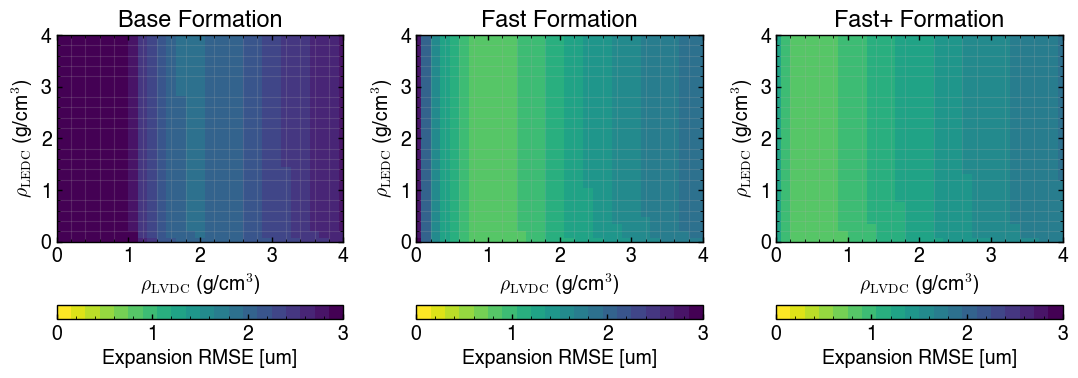

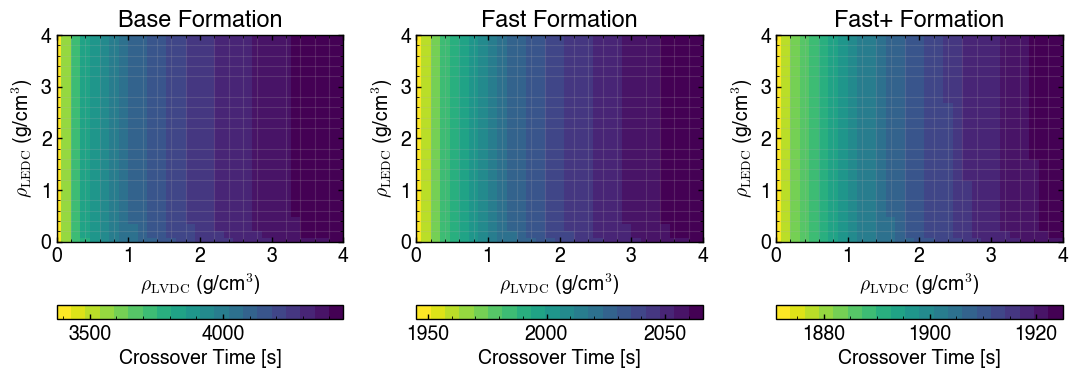

In [14]:
%autoreload 2

%matplotlib inline
# Load the pickled simulation results
with open('outputs/simulation_results_density_vc_20260120.pkl', 'rb') as f:
    sim_results = pickle.load(f)
diff_ec_vec = np.linspace(0.0, 4.0, 30)
diff_vc_vec = np.linspace(0.0, 4.0, 31)

# Extract variables from the loaded results
rmse1_e_mat = sim_results['rmse1_e_mat']
rmse1_v_mat = sim_results['rmse1_v_mat']
rmse2_e_mat = sim_results['rmse2_e_mat'] 
rmse2_v_mat = sim_results['rmse2_v_mat']
rmse3_e_mat = sim_results['rmse3_e_mat']
rmse3_v_mat = sim_results['rmse3_v_mat']
qsei1_mat = sim_results['qsei1_mat']
qsei2_mat = sim_results['qsei2_mat']
qsei3_mat = sim_results['qsei3_mat']
qsei1_vc_mat = sim_results['qsei1_vc_mat']
qsei2_vc_mat = sim_results['qsei2_vc_mat']
qsei3_vc_mat = sim_results['qsei3_vc_mat']
expan1_mat = sim_results['expan1_mat']
expan2_mat = sim_results['expan2_mat']
expan3_mat = sim_results['expan3_mat']
resistance1_mat = sim_results['resistance1_mat']
resistance2_mat = sim_results['resistance2_mat']
resistance3_mat = sim_results['resistance3_mat']
combined_rmse1 = sim_results['combined_rmse1']
combined_rmse2 = sim_results['combined_rmse2']
combined_rmse3 = sim_results['combined_rmse3']
eq1_mat = sim_results['eq1_mat']
eq2_mat = sim_results['eq2_mat']
eq3_mat = sim_results['eq3_mat']
er1_mat = sim_results['er1_mat'] 
er2_mat = sim_results['er2_mat']
er3_mat = sim_results['er3_mat']
ec1_mat = sim_results['ec1_mat']
ec2_mat = sim_results['ec2_mat']
ec3_mat = sim_results['ec3_mat']
crossover1_mat = sim_results['crossover1_mat']
crossover2_mat = sim_results['crossover2_mat']
crossover3_mat = sim_results['crossover3_mat']


simutils.plot_heatmaps_rho(diff_ec_vec, diff_vc_vec, rmse1_v_mat, rmse2_v_mat, rmse3_v_mat, 'Voltage RMSE [V]', 
                                   zmin=0, zmax=0.25, tosave=True, savename='outputs/figures/heatmap_rho_rmse_v.svg')
simutils.plot_heatmaps_rho(diff_ec_vec, diff_vc_vec, rmse1_e_mat, rmse2_e_mat, rmse3_e_mat, 'Expansion RMSE [um]', 
                                   zmin=0, zmax=3, tosave=True, savename='outputs/figures/heatmap_rho_rmse_e.svg')
simutils.plot_heatmaps_rho(diff_ec_vec, diff_vc_vec, crossover1_mat, crossover2_mat, crossover3_mat, 'Crossover Time [s]', 
                                   tosave=True, savename='outputs/figures/heatmap_rho_crossover.svg')